In [1]:
!pip install -q giotto-tda

!pip install gudhi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 94.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.6/554.6 kB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.8/455.8 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 7.6 MB/s eta 0:00:00


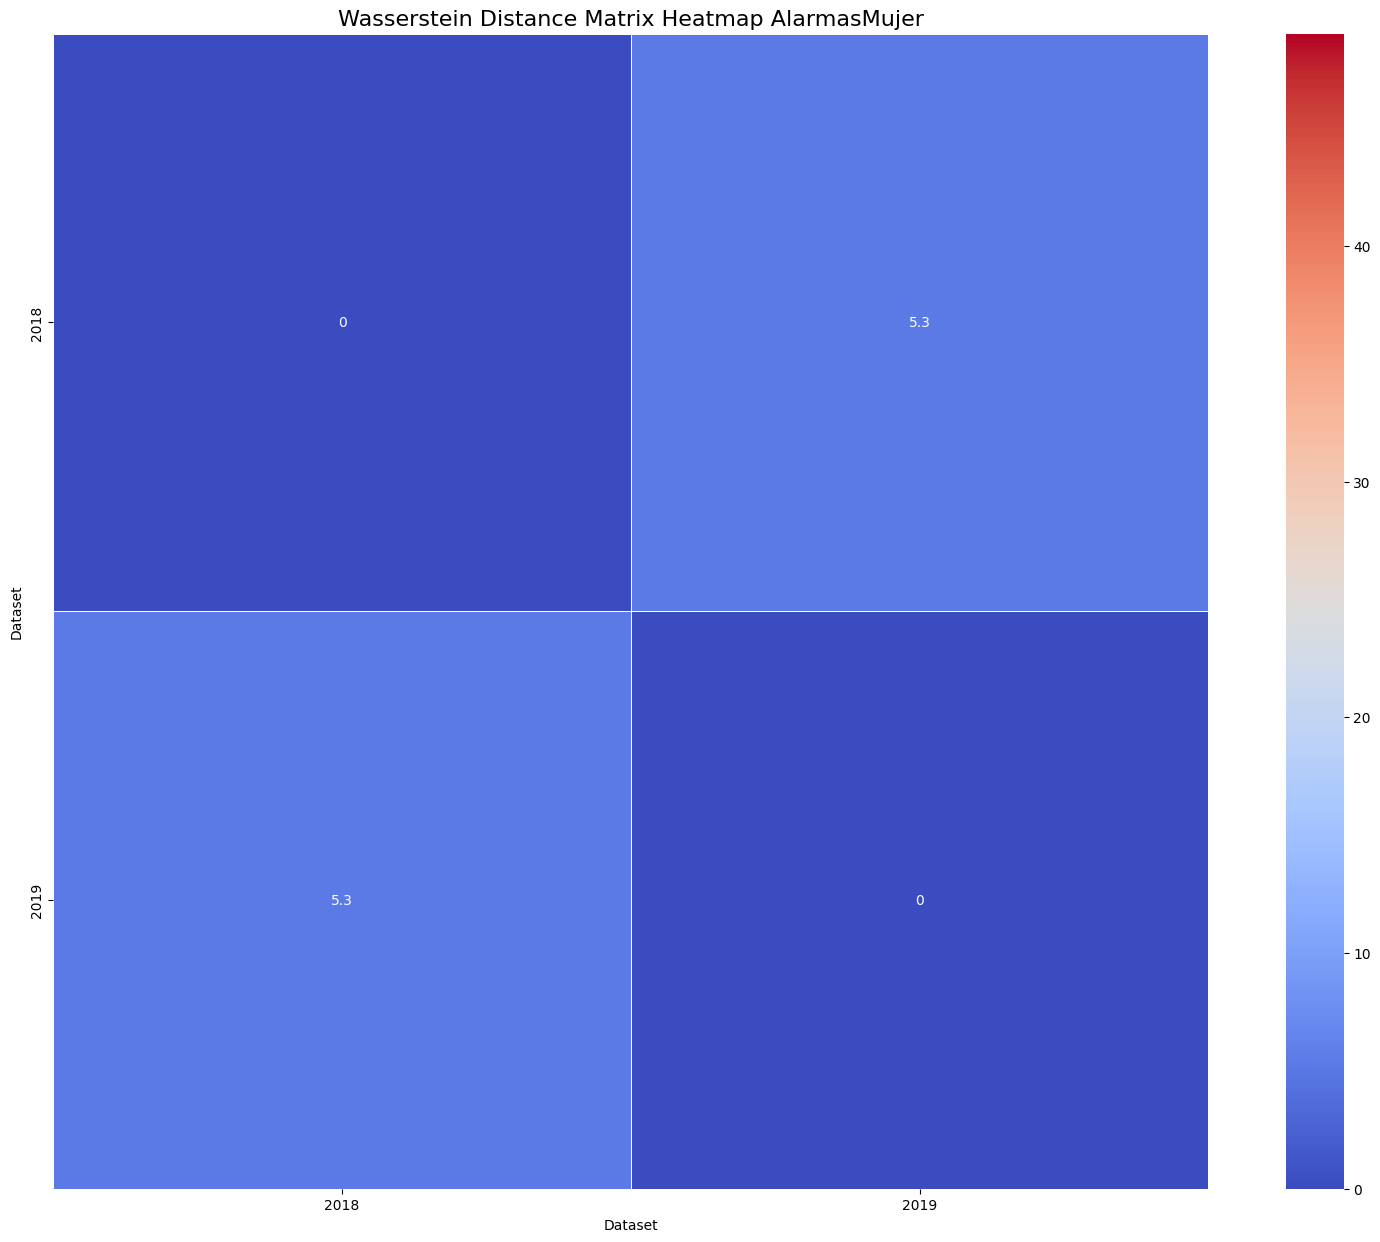

<function matplotlib.pyplot.ylabel(ylabel, fontdict=None, labelpad=None, *, loc=None, **kwargs)>

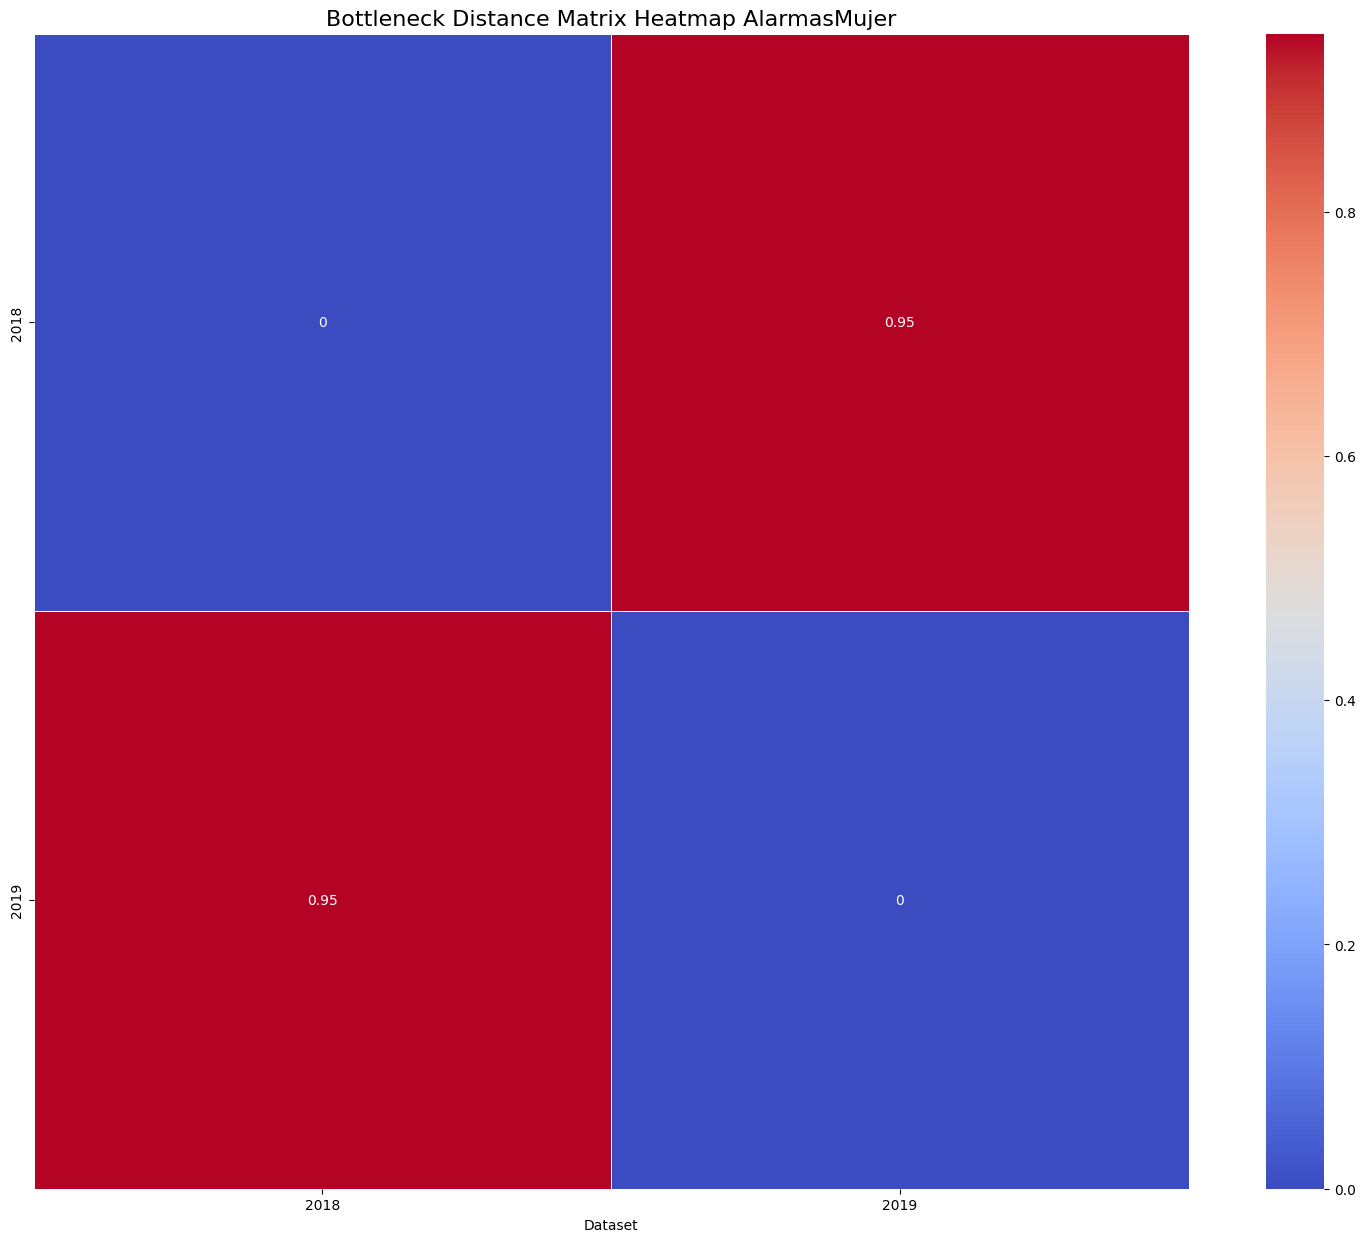

In [ ]:
import pandas as pd
import numpy as np
from gtda.homology import VietorisRipsPersistence
from scipy.stats import wasserstein_distance
from gudhi import bottleneck_distance
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Constante aleatoria para la resta en la distancia Wasserstein
distancia_aleatoria_wasserstein = 0.041638627496522

# Función para cargar datos, calcular el diagrama de persistencia y devolver solo nacimiento y muerte
def calculate_persistence_diagram(file_path):
    df = pd.read_csv(file_path)
    data = df[['crime_lon', 'crime_lat']].values
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)

    VR = VietorisRipsPersistence()
    diagrams = VR.fit_transform([data_scaled])

    # Filtrar el diagrama para solo incluir las columnas de nacimiento y muerte
    persistence_diagram = diagrams[0][:, :2]  # Tomar solo las primeras dos columnas: nacimiento y muerte
    return persistence_diagram

# Función para calcular la distancia de Wasserstein entre dos diagramas
def wasserstein_distance_between_diagrams(diag1, diag2):
    max_len = max(len(diag1), len(diag2))
    births1, deaths1 = diag1[:, 0], diag1[:, 1]
    births2, deaths2 = diag2[:, 0], diag2[:, 1]

    # Rellenar con NaN para igualar las longitudes de los vectores
    births1 = np.pad(births1, (0, max_len - len(births1)), constant_values=np.nan)
    deaths1 = np.pad(deaths1, (0, max_len - len(deaths1)), constant_values=np.nan)
    births2 = np.pad(births2, (0, max_len - len(births2)), constant_values=np.nan)
    deaths2 = np.pad(deaths2, (0, max_len - len(deaths2)), constant_values=np.nan)

    # Calcular las distancias Wasserstein para nacimientos y muertes
    distance_births = wasserstein_distance(births1[~np.isnan(births1)], births2[~np.isnan(births2)])
    distance_deaths = wasserstein_distance(deaths1[~np.isnan(deaths1)], deaths2[~np.isnan(deaths2)])

    return distance_births + distance_deaths

# Función para calcular la distancia Bottleneck entre dos diagramas
def bottleneck_distance_between_diagrams(diag1, diag2):
    return bottleneck_distance(diag1, diag2)

# Función para calcular las dos matrices de distancias
def calculate_both_distance_matrices(diagrams):
    num_diagrams = len(diagrams)
    wasserstein_matrix = np.zeros((num_diagrams, num_diagrams))
    bottleneck_matrix = np.zeros((num_diagrams, num_diagrams))

    for i in range(num_diagrams):
        for j in range(i + 1, num_diagrams):
            # Calcular distancia de Wasserstein
            wasserstein_dist = wasserstein_distance_between_diagrams(diagrams[i], diagrams[j])
            wasserstein_matrix[i, j] = wasserstein_dist
            wasserstein_matrix[j, i] = wasserstein_dist

            # Calcular distancia Bottleneck
            bottleneck_dist = bottleneck_distance_between_diagrams(diagrams[i], diagrams[j])
            bottleneck_matrix[i, j] = bottleneck_dist
            bottleneck_matrix[j, i] = bottleneck_dist

    return wasserstein_matrix, bottleneck_matrix

# Archivos CSV
files = [
    'Valencia_2018_AlarmasMujer_sampled.csv',
    'Valencia_2019_AlarmasMujer_sampled.csv'
]

# Calcular diagramas de persistencia una sola vez
diagrams = [calculate_persistence_diagram(file) for file in files]

# Calcular ambas matrices de distancias
wasserstein_matrix, bottleneck_matrix = calculate_both_distance_matrices(diagrams)

# Ajustar la matriz de distancias Wasserstein restando la constante aleatoria (excepto en la diagonal)
wasserstein_matrix_adjusted = wasserstein_matrix.copy()
np.fill_diagonal(wasserstein_matrix_adjusted, 0)
wasserstein_matrix_adjusted = np.where(np.eye(wasserstein_matrix.shape[0]), 0, wasserstein_matrix_adjusted - distancia_aleatoria_wasserstein)

# Nombres de los datasets
csv_names = ['2018', '2019']

wasserstein_matrix_scaled = wasserstein_matrix_adjusted * 1000

# Crear un heatmap para la matriz Wasserstein escalada
plt.figure(figsize=(20, 15))
sns.heatmap(wasserstein_matrix_scaled, annot=True, cmap="coolwarm", cbar=True, square=True, linewidths=.5,
            xticklabels=csv_names, yticklabels=csv_names, vmin=0, vmax=49)

# Añadir etiquetas a los ejes
plt.title('Wasserstein Distance Matrix Heatmap AlarmasMujer', fontsize=16)
plt.xlabel('Dataset')
plt.ylabel('Dataset')

# Mostrar el heatmap ajustado y escalado de Wasserstein
plt.show()

# Crear un heatmap para la distancia Bottleneck sin ajuste
plt.figure(figsize=(20, 15))
sns.heatmap(bottleneck_matrix, annot=True, cmap="coolwarm", cbar=True, square=True, linewidths=.5,
            xticklabels=csv_names, yticklabels=csv_names)

# Añadir etiquetas a los ejes
plt.title('Bottleneck Distance Matrix Heatmap AlarmasMujer', fontsize=16)
plt.xlabel('Dataset')
plt.ylabel



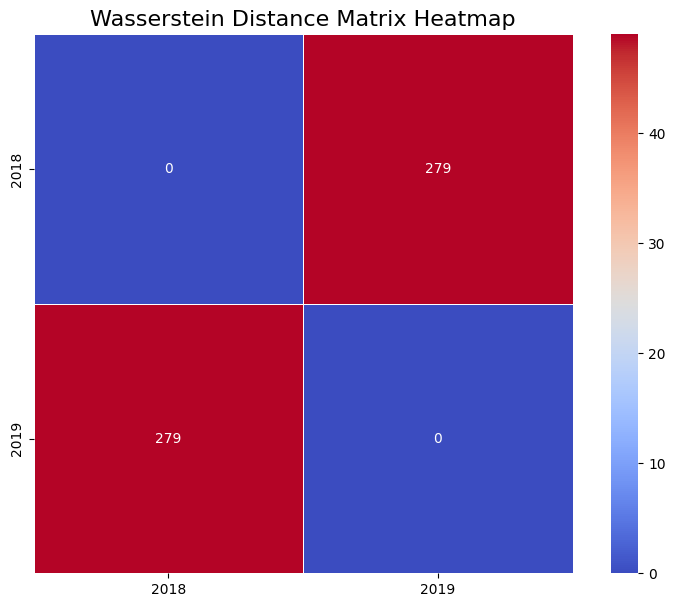

In [14]:
import pandas as pd
import numpy as np
from gtda.homology import VietorisRipsPersistence
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Constante aleatoria para la resta en la distancia Wasserstein
distancia_aleatoria_wasserstein = 0.08814432647284215

# Función para cargar datos, calcular el diagrama de persistencia y devolverlo completo
def calculate_persistence_diagram(file_path):
    df = pd.read_csv(file_path)

    # Seleccionar las columnas de longitud, latitud y día
    data = df[['crime_lon', 'crime_lat', 'day']].values
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)

    VR = VietorisRipsPersistence(homology_dimensions=[0, 1, 2])  # Incluyendo dimensiones 0, 1 y 2
    diagrams = VR.fit_transform([data_scaled])

    return diagrams[0]  # Retorna el diagrama completo (dimensiones 0, 1 y 2)

# Función para calcular la distancia de Wasserstein entre diagramas de diferentes dimensiones
def wasserstein_distance_between_diagrams(diag1, diag2):
    total_distance = 0
    for dim in range(3):  # Para las dimensiones 0, 1 y 2
        diag1_dim = diag1[diag1[:, 2] == dim][:, :2]  # Filtrar por dimensión y tomar nacimiento y muerte
        diag2_dim = diag2[diag2[:, 2] == dim][:, :2]

        max_len = max(len(diag1_dim), len(diag2_dim))
        births1, deaths1 = diag1_dim[:, 0], diag1_dim[:, 1]
        births2, deaths2 = diag2_dim[:, 0], diag2_dim[:, 1]

        # Rellenar con NaN para igualar las longitudes de los vectores
        births1 = np.pad(births1, (0, max_len - len(births1)), constant_values=np.nan)
        deaths1 = np.pad(deaths1, (0, max_len - len(deaths1)), constant_values=np.nan)
        births2 = np.pad(births2, (0, max_len - len(births2)), constant_values=np.nan)
        deaths2 = np.pad(deaths2, (0, max_len - len(deaths2)), constant_values=np.nan)

        # Calcular las distancias Wasserstein para nacimientos y muertes en cada dimensión
        distance_births = wasserstein_distance(births1[~np.isnan(births1)], births2[~np.isnan(births2)])
        distance_deaths = wasserstein_distance(deaths1[~np.isnan(deaths1)], deaths2[~np.isnan(deaths2)])

        # Sumar las distancias de cada dimensión
        total_distance += distance_births + distance_deaths

    return total_distance

# Función para calcular la matriz de distancias Wasserstein entre múltiples diagramas
def calculate_wasserstein_matrix(diagrams):
    num_diagrams = len(diagrams)
    wasserstein_matrix = np.zeros((num_diagrams, num_diagrams))

    for i in range(num_diagrams):
        for j in range(i + 1, num_diagrams):
            # Calcular distancia de Wasserstein entre diagramas i y j
            wasserstein_dist = wasserstein_distance_between_diagrams(diagrams[i], diagrams[j])
            wasserstein_matrix[i, j] = wasserstein_dist
            wasserstein_matrix[j, i] = wasserstein_dist

    return wasserstein_matrix

# Archivos CSV
files = [
    'Valencia_2018_AlarmasMujer_DAY_sorted.csv',
    'Valencia_2019_AlarmasMujer_DAY_sorted.csv'
]

# Calcular diagramas de persistencia para cada archivo
diagrams = [calculate_persistence_diagram(file) for file in files]

# Calcular la matriz de distancias Wasserstein entre todos los diagramas
wasserstein_matrix = calculate_wasserstein_matrix(diagrams)

# Ajustar la matriz de distancias Wasserstein restando la constante aleatoria (excepto en la diagonal)
wasserstein_matrix_adjusted = wasserstein_matrix.copy()
np.fill_diagonal(wasserstein_matrix_adjusted, 0)
wasserstein_matrix_adjusted = np.where(np.eye(wasserstein_matrix.shape[0]), 0, wasserstein_matrix_adjusted - distancia_aleatoria_wasserstein)

# Escalar la matriz ajustada multiplicando por 1000
wasserstein_matrix_scaled = wasserstein_matrix_adjusted * 1000

# Nombres de los datasets
csv_names = ['2018', '2019']

# Crear un heatmap para la matriz Wasserstein ajustada y escalada
# Crear un heatmap para la matriz Wasserstein ajustada y escalada
# Crear un heatmap para la matriz Wasserstein ajustada y escalada
plt.figure(figsize=(10, 7))

# Redondear los valores de la matriz para evitar notación científica
wasserstein_matrix_scaled_int = np.round(wasserstein_matrix_scaled).astype(int)

sns.heatmap(wasserstein_matrix_scaled_int, annot=True, fmt="d", cmap="coolwarm", cbar=True, square=True, linewidths=.5,
            xticklabels=csv_names, yticklabels=csv_names, vmin=0, vmax=49)

# Añadir etiquetas a los ejes
plt.title('Wasserstein Distance Matrix Heatmap', fontsize=16)

# Mostrar el heatmap ajustado y escalado de Wasserstein
plt.show()



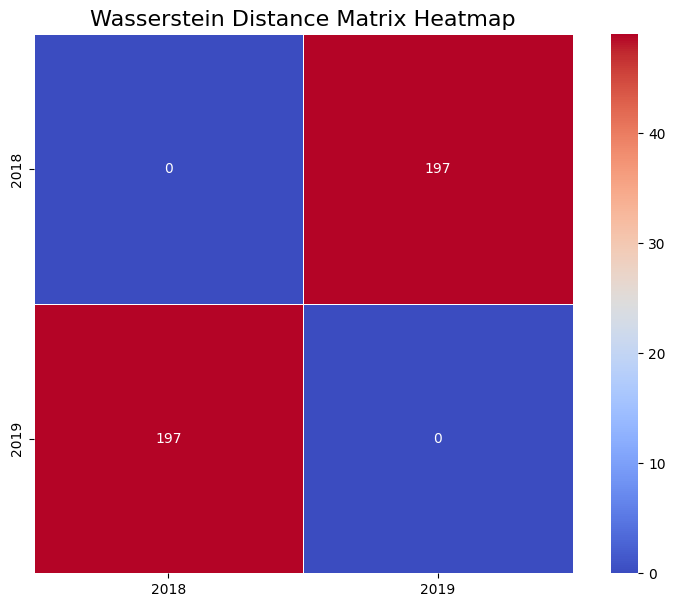

In [15]:
import pandas as pd
import numpy as np
from gtda.homology import VietorisRipsPersistence
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Constante aleatoria para la resta en la distancia Wasserstein
distancia_aleatoria_wasserstein = 0.00038579752191809404

# Función para cargar datos, calcular el diagrama de persistencia y devolverlo completo (dimensiones 0 y 1)
def calculate_persistence_diagram_2d(file_path):
    df = pd.read_csv(file_path)

    # Seleccionar las columnas de longitud y latitud (sin 'day')
    data = df[['crime_lon', 'crime_lat']].values
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)

    # Calcular el diagrama de persistencia (solo dimensiones 0 y 1)
    VR = VietorisRipsPersistence(homology_dimensions=[0, 1])  # Dimensiones 0 y 1
    diagrams = VR.fit_transform([data_scaled])

    return diagrams[0]  # Retorna el diagrama completo (dimensiones 0 y 1)

# Función para calcular la distancia de Wasserstein entre diagramas de diferentes dimensiones (dimensiones 0 y 1)
def wasserstein_distance_between_diagrams_2d(diag1, diag2):
    total_distance = 0
    for dim in range(2):  # Para las dimensiones 0 y 1
        diag1_dim = diag1[diag1[:, 2] == dim][:, :2]  # Filtrar por dimensión y tomar nacimiento y muerte
        diag2_dim = diag2[diag2[:, 2] == dim][:, :2]

        max_len = max(len(diag1_dim), len(diag2_dim))
        births1, deaths1 = diag1_dim[:, 0], diag1_dim[:, 1]
        births2, deaths2 = diag2_dim[:, 0], diag2_dim[:, 1]

        # Rellenar con NaN para igualar las longitudes de los vectores
        births1 = np.pad(births1, (0, max_len - len(births1)), constant_values=np.nan)
        deaths1 = np.pad(deaths1, (0, max_len - len(deaths1)), constant_values=np.nan)
        births2 = np.pad(births2, (0, max_len - len(births2)), constant_values=np.nan)
        deaths2 = np.pad(deaths2, (0, max_len - len(deaths2)), constant_values=np.nan)

        # Calcular las distancias Wasserstein para nacimientos y muertes en cada dimensión
        distance_births = wasserstein_distance(births1[~np.isnan(births1)], births2[~np.isnan(births2)])
        distance_deaths = wasserstein_distance(deaths1[~np.isnan(deaths1)], deaths2[~np.isnan(deaths2)])

        # Sumar las distancias de cada dimensión
        total_distance += distance_births + distance_deaths

    return total_distance

# Función para calcular la matriz de distancias Wasserstein entre múltiples diagramas (dimensiones 0 y 1)
def calculate_wasserstein_matrix_2d(diagrams):
    num_diagrams = len(diagrams)
    wasserstein_matrix = np.zeros((num_diagrams, num_diagrams))

    for i in range(num_diagrams):
        for j in range(i + 1, num_diagrams):
            # Calcular distancia de Wasserstein entre diagramas i y j
            wasserstein_dist = wasserstein_distance_between_diagrams_2d(diagrams[i], diagrams[j])
            wasserstein_matrix[i, j] = wasserstein_dist
            wasserstein_matrix[j, i] = wasserstein_dist

    return wasserstein_matrix

# Archivos CSV
files = [
    'Valencia_2018_AlarmasMujer_DAY_sorted.csv',
    'Valencia_2019_AlarmasMujer_DAY_sorted.csv'
]

# Calcular diagramas de persistencia para cada archivo (solo dimensiones 0 y 1)
diagrams = [calculate_persistence_diagram_2d(file) for file in files]

# Calcular la matriz de distancias Wasserstein entre todos los diagramas
wasserstein_matrix = calculate_wasserstein_matrix_2d(diagrams)

# Ajustar la matriz de distancias Wasserstein restando la constante aleatoria (excepto en la diagonal)
wasserstein_matrix_adjusted = wasserstein_matrix.copy()
np.fill_diagonal(wasserstein_matrix_adjusted, 0)
wasserstein_matrix_adjusted = np.where(np.eye(wasserstein_matrix.shape[0]), 0, wasserstein_matrix_adjusted - distancia_aleatoria_wasserstein)

# Escalar la matriz ajustada multiplicando por 1000
wasserstein_matrix_scaled = wasserstein_matrix_adjusted * 1000

# Nombres de los datasets
csv_names = ['2018', '2019']

# Crear un heatmap para la matriz Wasserstein ajustada y escalada
plt.figure(figsize=(10, 7))

# Redondear los valores de la matriz para evitar notación científica
wasserstein_matrix_scaled_int = np.round(wasserstein_matrix_scaled).astype(int)

sns.heatmap(wasserstein_matrix_scaled_int, annot=True, fmt="d", cmap="coolwarm", cbar=True, square=True, linewidths=.5,
            xticklabels=csv_names, yticklabels=csv_names, vmin=0, vmax=49)

# Añadir etiquetas a los ejes
plt.title('Wasserstein Distance Matrix Heatmap', fontsize=16)

# Mostrar el heatmap ajustado y escalado de Wasserstein
plt.show()
